# 05 — Analysis

Load the trained checkpoint, evaluate per-state prediction accuracy,
and compare the model's learned transition probabilities to the true
Gambler's Ruin matrix.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Load model & data

In [2]:
import sys

# Resolve project root and add project-local packages/ to sys.path.
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt_root = cwd / "projects" / "markov-chain-learning"
    if (alt_root / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt_root

if project_root is None:
    raise RuntimeError(
        "Could not locate markov-chain-learning project root from current working directory"
    )

packages_dir = project_root / "packages"
if str(packages_dir) not in sys.path:
    sys.path.insert(0, str(packages_dir))

from pytorch_models import MarkovTransformer

In [3]:
DATA_DIR = str(project_root / "experiments" / "single-chain" / "data")
DATA_DIR = Path(DATA_DIR)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


In [4]:
checkpoint_path = DATA_DIR / "checkpoint.pt"
if not checkpoint_path.exists():
    candidates = sorted(DATA_DIR.glob("checkpoint_*.pt"))
    if not candidates:
        raise FileNotFoundError("No checkpoint found in data directory.")
    checkpoint_path = max(candidates, key=lambda p: p.stat().st_mtime)

ckpt = torch.load(checkpoint_path, weights_only=False)
cfg = ckpt["config"]
training_meta = ckpt.get("training", {})

model = MarkovTransformer(**cfg)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(
    f"Loaded {checkpoint_path.name} from epoch {ckpt['epoch']} "
    f"(val loss {ckpt['best_val_loss']:.4f})"
)

data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
Ts = data["Ts"]
pis = data["pis"]
seqs = data["sequences"]
chain_to_sample = data["chain_to_sample"]
data_cfg = data.get("config", {})

VOCAB = int(cfg["vocab_size"])
PAD_ID = int(data_cfg.get("pad_id", -1))

if Ts.shape[0] == 1:
    T_reference = Ts[0]
    pi_reference = pis[0]
else:
    chain_weights = torch.bincount(chain_to_sample, minlength=Ts.shape[0]).float()
    chain_weights = chain_weights / chain_weights.sum()
    T_reference = (chain_weights[:, None, None] * Ts).sum(dim=0)
    pi_reference = (chain_weights[:, None] * pis).sum(dim=0)

print(f"DGP regime: {data_cfg.get('dgp_regime', 'unknown')}")
print(f"Reference T shape: {tuple(T_reference.shape)}")

Loaded checkpoint_single_chain.pt from epoch 92 (val loss 1.2749)
DGP regime: single
Reference T shape: (5, 5)


## Training curve vs generalization loss

Load per-epoch checkpoints saved during training.  For each epoch, compute
the scalar generalization loss on a fixed held-out test set (same sequences
reused across epochs so the curve is comparable).  Plot together with the
training and validation loss curves and the Bayes-optimal NLL as a reference.

A well-trained model should show:
- Train ≈ Val ≈ Gen all converging toward Bayes NLL
- Gen loss slightly above Val loss (generalization gap)


Epoch checkpoints:   0%|          | 0/10 [00:00<?, ?ckpt/s]

Eval epoch 10:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 20:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 30:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 40:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Eval epoch 60:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 70:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 80:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 90:   0%|          | 0/1 [00:00<?, ?batch/s]

Eval epoch 100:   0%|          | 0/1 [00:00<?, ?batch/s]

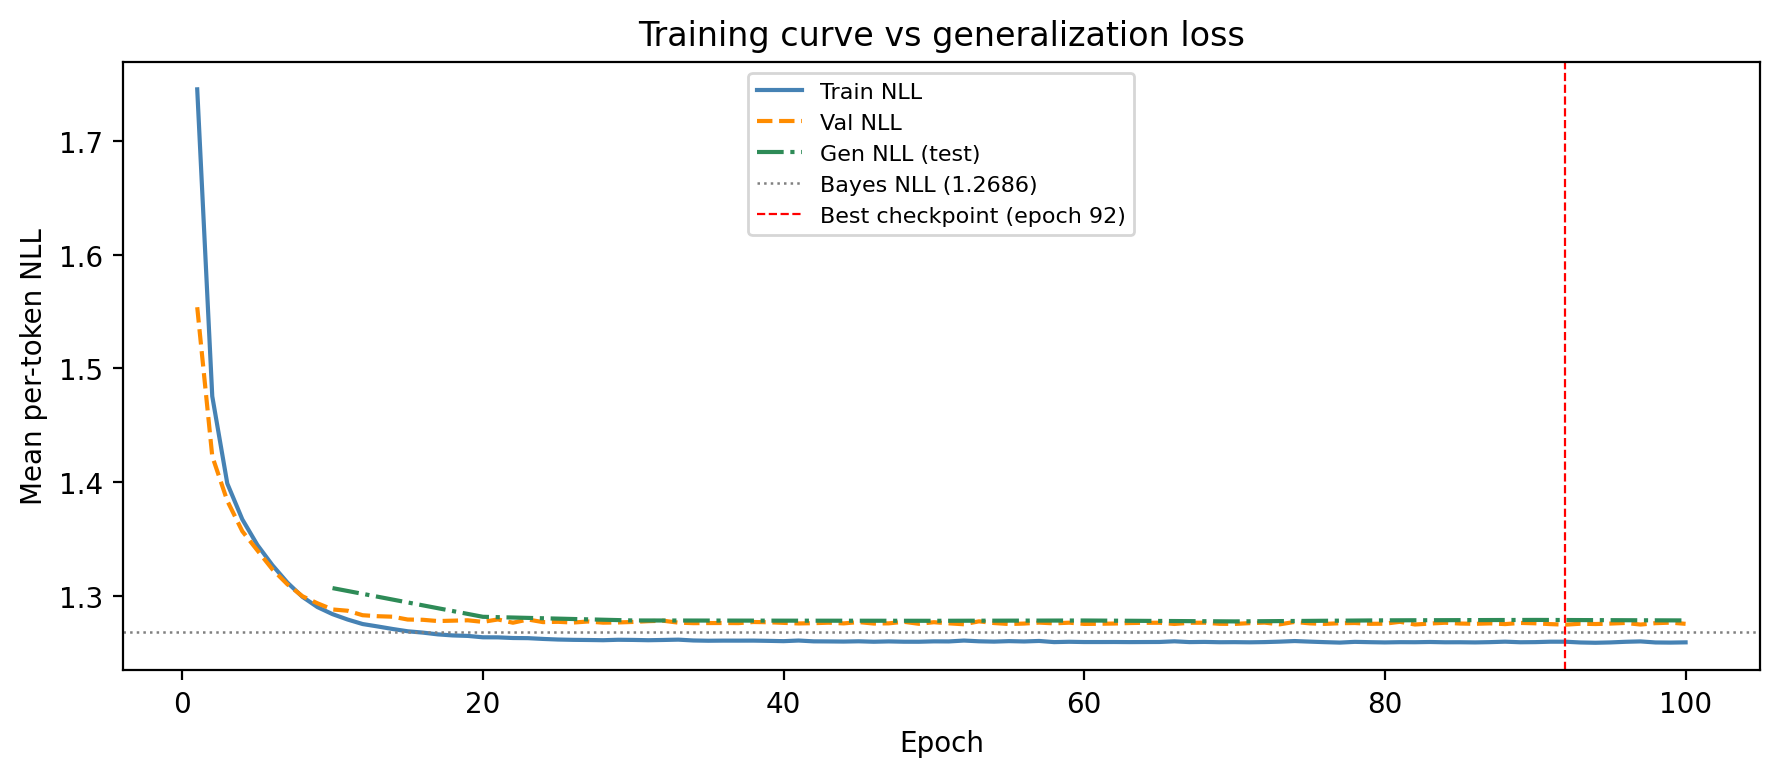

Final  train NLL : 1.259345
Final  val   NLL : 1.275614
Final  gen   NLL : 1.278609
Gen − Bayes gap  : 0.010002
Bayes-optimal NLL: 1.268606


In [5]:
import numpy as np
from markov_chain import sample_sequences
from tqdm.auto import tqdm

history_path = DATA_DIR / "training_history.pt"
checkpoints_dir = DATA_DIR / "checkpoints"

if not history_path.exists():
    print("No training_history.pt found — re-run 04_training.ipynb first.")
else:
    history = torch.load(history_path, weights_only=False)
    epochs = history["epochs"]
    train_losses = history["train_losses"]
    val_losses = history["val_losses"]

    # ── Fixed test set (reused across all epoch checkpoints) ─────────────────
    _max_len = int(data_cfg.get("seq_len", cfg.get("max_seq_len", 32)))
    _N = 100
    _rng = np.random.default_rng(0)
    _lengths = _rng.integers(low=2, high=_max_len + 1, size=_N)
    _seqs_np = sample_sequences(
        T_reference.numpy(),
        n=_N,
        seq_len=_max_len,
        prior=pi_reference.numpy(),
        rng=0,
    )
    _seqs = torch.from_numpy(_seqs_np).long()
    _x_in = _seqs[:, :-1]
    _x_tgt = _seqs[:, 1:]
    _valid = torch.arange(_max_len - 1) < (
        torch.from_numpy(_lengths).unsqueeze(1) - 1
    )  # (N, max_len-1)
    _log_T = torch.log(T_reference.clamp_min(1e-12))
    _valid_np = _valid.numpy()

    # Bayes NLL is model-independent — compute once
    _lpb = _log_T[_x_in, _x_tgt].float().numpy()
    bayes_nll = float(-_lpb[_valid_np].mean())

    # ── Loop over per-epoch checkpoints ──────────────────────────────────────
    ckpt_files = sorted(checkpoints_dir.glob("checkpoint_epoch_*.pt"))
    if not ckpt_files:
        print(f"No per-epoch checkpoints found in {checkpoints_dir}")
    else:
        gen_losses = []
        gen_epochs = []
        for ckpt_file in tqdm(ckpt_files, desc="Epoch checkpoints", unit="ckpt"):
            ep_ckpt = torch.load(ckpt_file, weights_only=False)
            ep = ep_ckpt["epoch"]

            ep_model = MarkovTransformer(**ep_ckpt["config"])
            ep_model.load_state_dict(ep_ckpt["model_state"])
            ep_model.eval()

            _lpm = torch.zeros(_N, _max_len - 1)
            with torch.no_grad():
                for start in tqdm(
                    range(0, _N, 512),
                    desc=f"Eval epoch {ep}",
                    unit="batch",
                    leave=False,
                ):
                    logits = ep_model(_x_in[start : start + 512])
                    lp = torch.log_softmax(logits, dim=-1)
                    tgt = _x_tgt[start : start + 512]
                    _lpm[start : start + 512] = lp.gather(
                        -1, tgt.unsqueeze(-1)
                    ).squeeze(-1)

            gen_nll = float(-_lpm.numpy()[_valid_np].mean())
            gen_losses.append(gen_nll)
            gen_epochs.append(ep)

        # ── Plot ─────────────────────────────────────────────────────────────
        best_epoch = ckpt["epoch"]

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(epochs, train_losses, label="Train NLL", color="steelblue")
        ax.plot(epochs, val_losses, label="Val NLL", color="darkorange", linestyle="--")
        ax.plot(
            gen_epochs,
            gen_losses,
            label="Gen NLL (test)",
            color="seagreen",
            linestyle="-.",
        )
        ax.axhline(
            bayes_nll,
            color="gray",
            linewidth=0.9,
            linestyle=":",
            label=f"Bayes NLL ({bayes_nll:.4f})",
        )
        ax.axvline(
            best_epoch,
            color="red",
            linewidth=0.8,
            linestyle="--",
            label=f"Best checkpoint (epoch {best_epoch})",
        )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Mean per-token NLL")
        ax.set_title("Training curve vs generalization loss")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        print(f"Final  train NLL : {train_losses[-1]:.6f}")

        print(f"Final  val   NLL : {val_losses[-1]:.6f}")

        print(f"Final  gen   NLL : {gen_losses[-1]:.6f}")
        print(f"Gen − Bayes gap  : {gen_losses[-1] - bayes_nll:.6f}")
        print(f"Bayes-optimal NLL: {bayes_nll:.6f}")

## Generalization loss vs sequence length

Sample `N` sequences with lengths drawn i.i.d. from
$l \sim \text{Uniform}\{2, \ldots, \text{max\_len}\}$.
Run the model on each; collect every valid per-step prediction as an
observation tagged with `(current_state, sequence_length)`.

Three diagnostics:

1. **NLL vs sequence length $l$** (line plot): mean per-token NLL across all
   positions within sequences of total length $l$.  Flat and close to the
   Bayes NLL = the model is length-invariant.

2. **Excess NLL heatmap** (state × $l$): for each (state, sequence-length)
   cell, mean excess NLL.  Should be uniformly near zero.

3. **Per-state excess** (bar chart): excess NLL marginalised over $l$.
   A spike at state $k$ means transitions *out of* $k$ were not learned
   uniformly across sequence lengths.


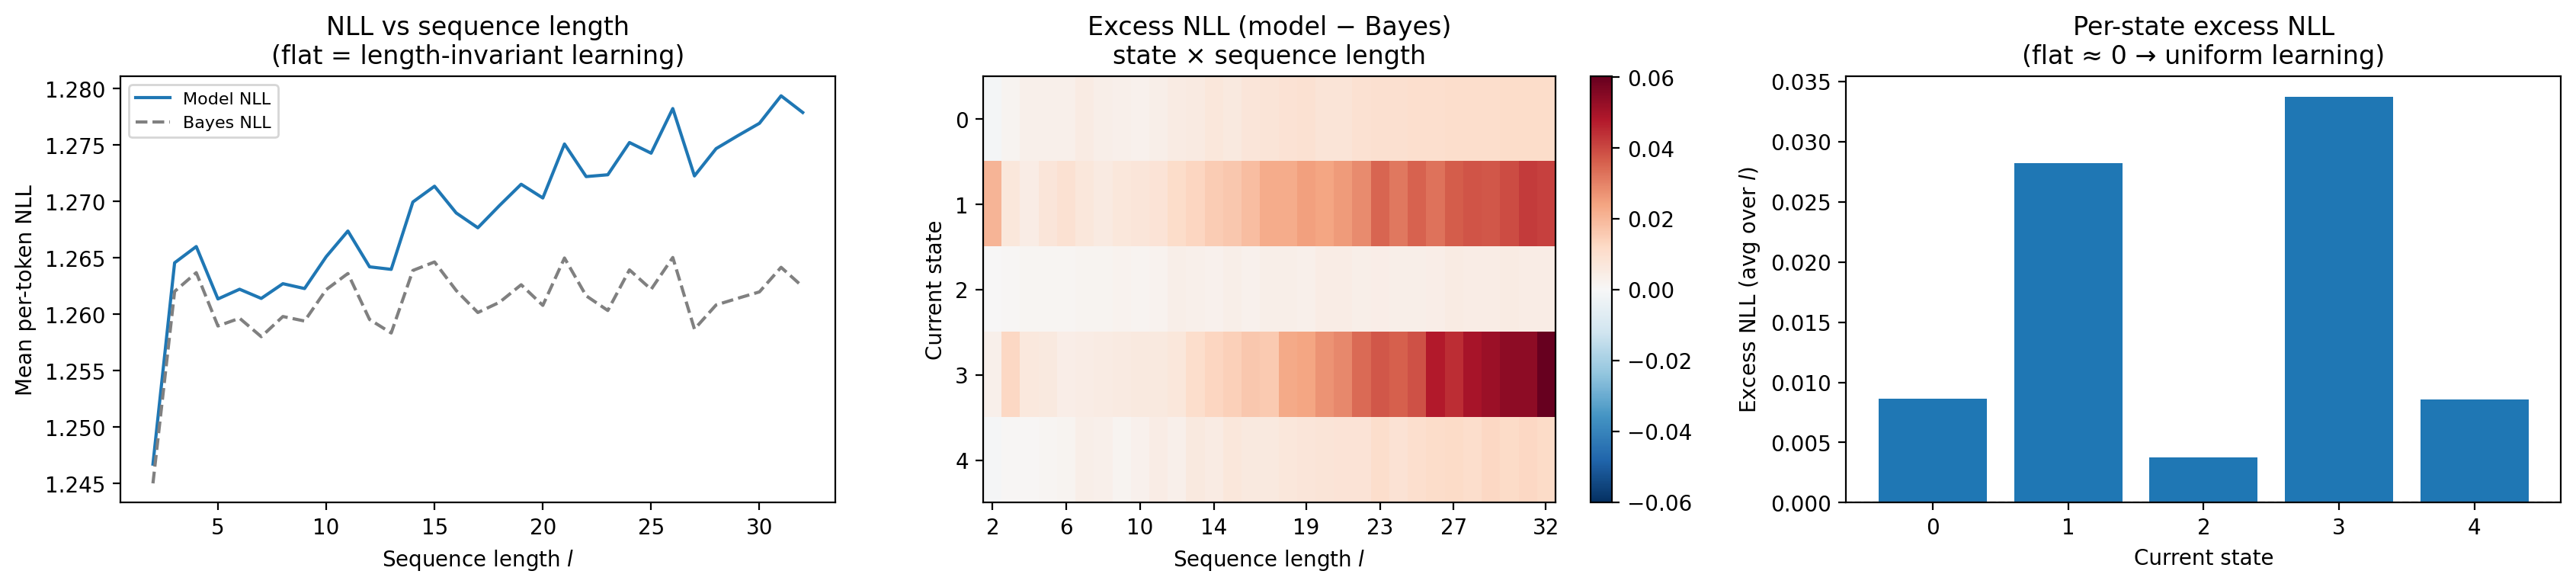

In [6]:
import numpy as np
from markov_chain import sample_sequences

max_len = int(data_cfg.get("seq_len", cfg.get("max_seq_len", 32)))
N_TEST = 250_000

# Draw sequence lengths i.i.d. from Uniform{2, ..., max_len}
rng_np = np.random.default_rng(42)
lengths = rng_np.integers(low=2, high=max_len + 1, size=N_TEST)  # (N,)

# Sample all sequences at max_len; the causal model means logits at position t
# only depend on x[0..t], so tokens beyond lengths[i]-1 are never "seen".
test_seqs_np = sample_sequences(
    T_reference.numpy(),
    n=N_TEST,
    seq_len=max_len,
    prior=pi_reference.numpy(),
    rng=42,
)
test_seqs = torch.from_numpy(test_seqs_np).long()  # (N, max_len)

x_in = test_seqs[:, :-1]  # (N, max_len-1)  context tokens
x_tgt = test_seqs[:, 1:]  # (N, max_len-1)  target tokens

# Position t (0-indexed) is valid for sequence i iff t+1 < lengths[i]
lengths_t = torch.from_numpy(lengths)
valid = torch.arange(max_len - 1) < (lengths_t.unsqueeze(1) - 1)  # (N, max_len-1)

# ── Model log-probs (full causal forward pass, then select valid entries) ─────
BATCH = 512
log_probs_model = torch.zeros(N_TEST, max_len - 1)
with torch.no_grad():
    for start in range(0, N_TEST, BATCH):
        logits = model(x_in[start : start + BATCH])
        lp = torch.log_softmax(logits, dim=-1)
        tgt = x_tgt[start : start + BATCH]
        log_probs_model[start : start + BATCH] = lp.gather(
            -1, tgt.unsqueeze(-1)
        ).squeeze(-1)

log_T = torch.log(T_reference.clamp_min(1e-12))
log_probs_bayes = log_T[x_in, x_tgt]  # (N, max_len-1)

# ── Flatten to per-observation arrays (only valid positions) ──────────────────
valid_np = valid.numpy()
flat_lpm = log_probs_model.numpy()[valid_np]  # model log-prob
flat_lpb = log_probs_bayes.float().numpy()[valid_np]  # Bayes log-prob
flat_state = x_in.numpy()[valid_np]  # current state
# sequence length for each observation
lengths_grid = np.tile(lengths[:, None], (1, max_len - 1))  # (N, max_len-1)
flat_len = lengths_grid[valid_np]  # in {2..max_len}

len_vals = np.arange(2, max_len + 1)

# ── 1. NLL vs sequence length ─────────────────────────────────────────────────
nll_model_by_l = np.array(
    [
        -flat_lpm[flat_len == l].mean() if (flat_len == l).any() else np.nan
        for l in len_vals
    ]
)
nll_bayes_by_l = np.array(
    [
        -flat_lpb[flat_len == l].mean() if (flat_len == l).any() else np.nan
        for l in len_vals
    ]
)

# ── 2. Per-(state, length) excess NLL heatmap ─────────────────────────────────
nll_st_model = np.full((VOCAB, len(len_vals)), np.nan)
nll_st_bayes = np.full((VOCAB, len(len_vals)), np.nan)

for li, l in enumerate(len_vals):
    mask_l = flat_len == l
    for s in range(VOCAB):
        mask_sl = mask_l & (flat_state == s)
        if mask_sl.any():
            nll_st_model[s, li] = -flat_lpm[mask_sl].mean()
            nll_st_bayes[s, li] = -flat_lpb[mask_sl].mean()

excess_st = nll_st_model - nll_st_bayes  # (VOCAB, len(len_vals))

# ── 3. Per-state excess, marginalising over length ────────────────────────────
excess_by_s = np.array(
    [
        -flat_lpm[flat_state == s].mean() + flat_lpb[flat_state == s].mean()
        if (flat_state == s).any()
        else np.nan
        for s in range(VOCAB)
    ]
)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Panel 1 — NLL vs sequence length
axes[0].plot(len_vals, nll_model_by_l, label="Model NLL")
axes[0].plot(len_vals, nll_bayes_by_l, linestyle="--", color="gray", label="Bayes NLL")
axes[0].set_xlabel("Sequence length $l$")
axes[0].set_ylabel("Mean per-token NLL")
axes[0].set_title("NLL vs sequence length\n(flat = length-invariant learning)")
axes[0].legend(fontsize=8)

# Panel 2 — Excess NLL heatmap (state × length)
vmax = float(np.nanmax(np.abs(excess_st))) or 1.0
tick_idx = np.linspace(0, len(len_vals) - 1, min(8, len(len_vals)), dtype=int)
im = axes[1].imshow(excess_st, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_xticks(tick_idx)
axes[1].set_xticklabels(len_vals[tick_idx])
axes[1].set_yticks(range(VOCAB))
axes[1].set_xlabel("Sequence length $l$")
axes[1].set_ylabel("Current state")
axes[1].set_title("Excess NLL (model − Bayes)\nstate × sequence length")
plt.colorbar(im, ax=axes[1])

# Panel 3 — Per-state excess, length marginalised
axes[2].bar(range(VOCAB), excess_by_s)
axes[2].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[2].set_xticks(range(VOCAB))
axes[2].set_xlabel("Current state")
axes[2].set_ylabel("Excess NLL (avg over $l$)")
axes[2].set_title("Per-state excess NLL\n(flat ≈ 0 → uniform learning)")

plt.tight_layout()
plt.show()

Recompute KL per checkpoint:   0%|          | 0/10 [00:00<?, ?ckpt/s]

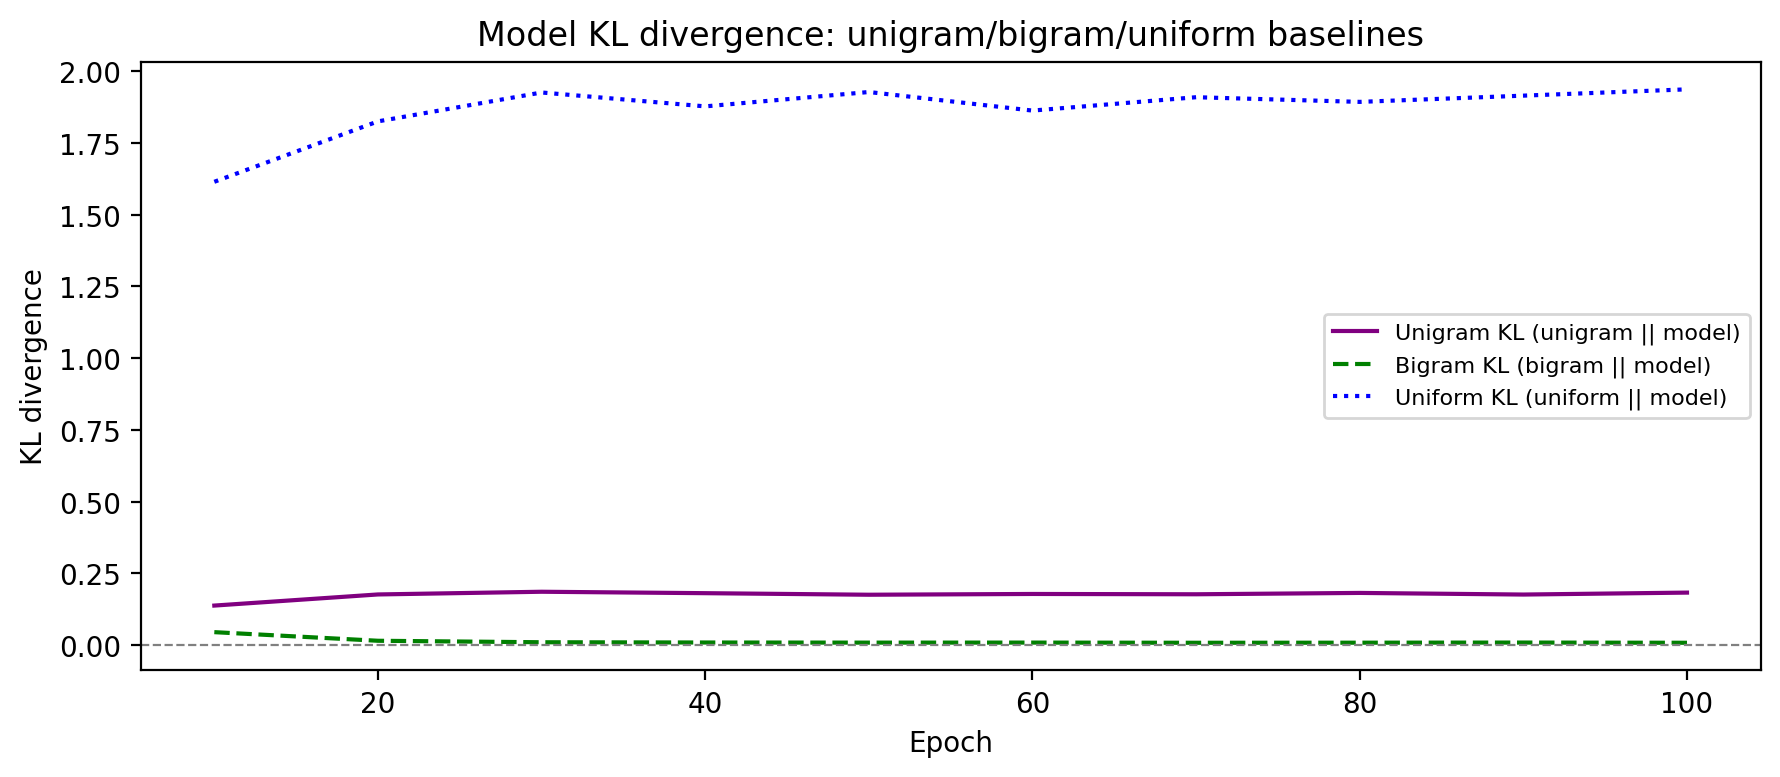

Final unigram KL: 0.183387
Final bigram KL: 0.008625
Final uniform KL: 1.936645


In [7]:
# --- Additional analysis: KL divergence from unigram (stationary) baseline ---
# compute gen_kl_unigram from scratch using checkpoint models
from tqdm.auto import tqdm

pi = torch.from_numpy(pi_reference.numpy()).float()
log_pi = torch.log(pi.clamp_min(1e-12))

ckpt_files = sorted(checkpoints_dir.glob("checkpoint_epoch_*.pt"))
if not ckpt_files:
    raise FileNotFoundError(f"No per-epoch checkpoints found in {checkpoints_dir}")

gen_epochs = []
gen_kl_unigram = []
gen_kl_bigram = []
gen_kl_uniform = []

uniform_prob = 1.0 / float(VOCAB)
log_uniform = torch.log(torch.tensor(uniform_prob, dtype=torch.float32))

for ckpt_file in tqdm(ckpt_files, desc="Recompute KL per checkpoint", unit="ckpt"):
    ep_ckpt = torch.load(ckpt_file, weights_only=False)
    ep = ep_ckpt["epoch"]

    ep_model = MarkovTransformer(**ep_ckpt["config"])
    ep_model.load_state_dict(ep_ckpt["model_state"])
    ep_model.eval()

    kl_uni_sum = 0.0
    kl_bi_sum = 0.0
    kl_uni_sum_uniform = 0.0
    kl_count = 0

    with torch.no_grad():
        for start in range(0, _N, 512):
            logits = ep_model(_x_in[start : start + 512])
            probs = torch.softmax(logits, dim=-1)

            # Unigram baseline KL(unigram || model)
            kl_uni = (
                pi[None, None, :]
                * (log_pi[None, None, :] - torch.log(probs.clamp_min(1e-12)))
            ).sum(dim=-1)

            # Bigram baseline KL(bigram || model), based on true transition rows
            p_bigram = T_reference[_x_in[start : start + 512]]
            log_p_bigram = torch.log(p_bigram.clamp_min(1e-12))
            kl_bi = (p_bigram * (log_p_bigram - torch.log(probs.clamp_min(1e-12)))).sum(
                dim=-1
            )

            valid_batch = _valid[start : start + 512]
            kl_uni_sum += float(kl_uni[valid_batch].sum().item())
            kl_bi_sum += float(kl_bi[valid_batch].sum().item())

            # Uniform baseline KL(uniform || model)
            kl_uniform = log_uniform - torch.log(probs.clamp_min(1e-12))
            kl_uniform = kl_uniform.sum(dim=-1)
            kl_uni_sum_uniform += float(kl_uniform[valid_batch].sum().item())

            kl_count += int(valid_batch.sum().item())

    gen_epochs.append(ep)
    gen_kl_unigram.append(float(kl_uni_sum / max(1, kl_count)))
    gen_kl_bigram.append(float(kl_bi_sum / max(1, kl_count)))
    gen_kl_uniform.append(float(kl_uni_sum_uniform / max(1, kl_count)))

fig3, ax3 = plt.subplots(figsize=(9, 4))
ax3.plot(
    gen_epochs,
    gen_kl_unigram,
    label="Unigram KL (unigram || model)",
    color="purple",
    linestyle="-",
)
ax3.plot(
    gen_epochs,
    gen_kl_bigram,
    label="Bigram KL (bigram || model)",
    color="green",
    linestyle="--",
)
ax3.plot(
    gen_epochs,
    gen_kl_uniform,
    label="Uniform KL (uniform || model)",
    color="blue",
    linestyle=":",
)
ax3.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax3.set_xlabel("Epoch")
ax3.set_ylabel("KL divergence")
ax3.set_title("Model KL divergence: unigram/bigram/uniform baselines")
ax3.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"Final unigram KL: {gen_kl_unigram[-1]:.6f}")
print(f"Final bigram KL: {gen_kl_bigram[-1]:.6f}")
print(f"Final uniform KL: {gen_kl_uniform[-1]:.6f}")

## Hessian curvature vs sample size

This section loads the sample-size sweep checkpoints from `04_training.ipynb`
(`sample_size_models/checkpoint_N_*.pt`) and computes the Hessian at each
sample-size MAP. The goal is to see how the MAP moves with increasing data, how
Hessian degeneracy evolves, and how the local profile-likelihood surface changes
with sample size.


In [ ]:
# Load sample-size sweep checkpoints and regenerate training data
from torch.nn.utils import parameters_to_vector, vector_to_parameters

sample_size_sweep_path = DATA_DIR / "sample_size_sweep.pt"
sample_size_model_dir = DATA_DIR / "sample_size_models"
SEED = 42

if not sample_size_sweep_path.exists():
    raise FileNotFoundError(
        "Run 04_training.ipynb first to generate sample-size MAP checkpoints. "
        "This notebook expects `sample_size_sweep.pt` and `sample_size_models/` to exist."
    )

sample_size_records = torch.load(sample_size_sweep_path, weights_only=False)
sample_size_records = sorted(sample_size_records, key=lambda r: int(r["N"]))

# Sequence length: this experiment's dataset config stores it as 'L'.
MAX_LEN = int(data_cfg.get("L", data_cfg.get("seq_len", cfg.get("max_len", 10))))


def load_sample_size_model(record):
    # 04 stores checkpoint_path as an absolute path; fall back to the bare
    # per-N name inside the model dir if it is missing or not a real file.
    raw = record.get("checkpoint_path")
    ckpt_path = Path(raw) if raw else None
    if ckpt_path is None or not ckpt_path.exists():
        ckpt_path = sample_size_model_dir / f"checkpoint_N_{int(record['N'])}.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing sample-size model checkpoint: {ckpt_path}")
    ckpt = torch.load(ckpt_path, weights_only=False)
    m = MarkovTransformer(**ckpt["config"])
    m.load_state_dict(ckpt["model_state"])  # 04 saves under 'model_state'
    m.eval()
    return m


def make_sample_data(N):
    seqs_np = sample_sequences(
        T_reference.numpy(),
        n=N,
        seq_len=MAX_LEN,
        prior=pi_reference.numpy(),
        rng=SEED + N,
    )
    seqs_local = torch.from_numpy(seqs_np).long()
    x = seqs_local[:, :-1].clone()
    y = seqs_local[:, 1:].clone()
    x[x == PAD_ID] = 0
    return x, y


def loss_fn(logits, targets):
    ce = F.cross_entropy(
        logits.reshape(-1, VOCAB),
        targets.reshape(-1),
        reduction="none",
        ignore_index=PAD_ID,
    )
    ce = ce.view(logits.shape[:-1])
    mask = (targets != PAD_ID).float()
    return (ce * mask).sum() / mask.sum()


from torch_bdn.bn.bayesian_net import approx_hessian

sample_size_results = []
for rec in sample_size_records:
    N = int(rec["N"])
    model_n = load_sample_size_model(rec)
    x_subset, y_subset = make_sample_data(N)
    H = approx_hessian(model_n, loss_fn, x_subset, y_subset, chunk_size=10240)
    eigvals, eigvecs = torch.linalg.eigh(H)
    eigvals = eigvals.cpu()
    eigvecs = eigvecs.cpu()
    theta = parameters_to_vector(model_n.parameters()).detach().cpu()
    max_eig = float(eigvals[-1].item())
    threshold = max(1e-12, max_eig * 1e-6)
    sample_size_results.append(
        {
            "N": N,
            "record": rec,
            "model": model_n,
            "theta": theta,
            "eigvals": eigvals,
            "eigvecs": eigvecs,
            "threshold": threshold,
            "flat_count": int((eigvals <= threshold).sum().item()),
            "negative_count": int((eigvals < 0).sum().item()),
            "condition_number": float(
                abs(eigvals[-1].item()) / max(abs(eigvals[0].item()), 1e-16)
            ),
        }
    )
    print(
        f"N={N}: min={eigvals[0]:.2e}, max={eigvals[-1]:.2e}, "
        f"neg={sample_size_results[-1]['negative_count']}, "
        f"flat<={threshold:.2e}: {sample_size_results[-1]['flat_count']}"
    )

In [ ]:
# ── Eigenspectrum evolution ACROSS sample size ──
# One Hessian per N (computed above). Show how the full spectrum changes with N.
Ns = [r["N"] for r in sample_size_results]
final_train = [r["record"]["final_train_loss"] for r in sample_size_results]
final_val = [r["record"]["final_val_loss"] for r in sample_size_results]
best_val = [r["record"]["best_val_loss"] for r in sample_size_results]
flat_counts = [r["flat_count"] for r in sample_size_results]
negative_counts = [r["negative_count"] for r in sample_size_results]
condition_numbers = [r["condition_number"] for r in sample_size_results]
min_eigs = [r["eigvals"][0].item() for r in sample_size_results]
max_eigs = [r["eigvals"][-1].item() for r in sample_size_results]

# DGP conditional entropy H(X'|X): irreducible per-token CE floor (loss → this, not 0).
_logT = torch.log(T_reference.clamp_min(1e-12))
cond_entropy = float(-(pi_reference[:, None] * T_reference * _logT).sum().item())

# (1) Full sorted spectrum overlaid, one curve per N.
eig_sorted = torch.stack(
    [torch.sort(r["eigvals"], descending=True).values for r in sample_size_results]
)  # (n_N, d)
ranks = np.arange(1, eig_sorted.shape[1] + 1)

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(Ns)))
for i, N in enumerate(Ns):
    ax.plot(ranks, eig_sorted[i].numpy(), color=cmap[i], lw=1.2, label=f"N={N}")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_yscale("symlog", linthresh=1e-4)
ax.set_xlabel("Eigenvalue rank (descending)")
ax.set_ylabel("λ (symlog)")
ax.set_title("Hessian eigenspectrum vs sample size (one curve per N)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (2) Heatmap: sample size × eigenvalue rank, colored by sign(λ)·log10|λ|.
signed_log = torch.sign(eig_sorted) * torch.log10(eig_sorted.abs() + 1e-12)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    signed_log.numpy(),
    aspect="auto",
    cmap="RdBu_r",
    origin="upper",
    vmin=-4.0,
    vmax=4.0,
    extent=[1, eig_sorted.shape[1], len(Ns) - 0.5, -0.5],
)
ax.set_yticks(range(len(Ns)))
ax.set_yticklabels(Ns)
ax.set_xlabel("Eigenvalue rank (descending)")
ax.set_ylabel("Sample size N")
ax.set_title(
    "Eigenspectrum evolution across sample size (sign(λ)·log₁₀|λ|, clipped ±4)"
)
plt.colorbar(im, ax=ax, label="sign(λ)·log₁₀|λ|  (white = degenerate)")
plt.tight_layout()
plt.show()

# (3) Learning curves vs N (loss converges to the entropy floor, not 0).
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(Ns, final_train, marker="o", label="Final train loss")
ax.semilogx(Ns, final_val, marker="s", label="Final val loss")
ax.semilogx(Ns, best_val, marker="^", label="Best val loss (kept checkpoint)")
ax.axhline(
    cond_entropy,
    color="gray",
    ls=":",
    lw=1.0,
    label=f"DGP entropy floor H(X'|X) = {cond_entropy:.3f}",
)
ax.set_xlabel("Sample size N")
ax.set_ylabel("Mean per-token NLL")
ax.set_title("Train / val NLL vs sample size")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# (4) Degeneracy / extreme eigenvalues / condition number vs N.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].semilogx(Ns, flat_counts, marker="o", label="Flat modes")
axes[0].semilogx(Ns, negative_counts, marker="s", label="Negative modes")
axes[0].set_xlabel("Sample size N")
axes[0].set_ylabel("Count")
axes[0].set_title("Hessian degeneracy at each MAP")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(
    Ns, np.log10(np.abs(min_eigs) + 1e-20), marker="o", label="log10(|λ_min|)"
)
axes[1].semilogx(Ns, np.log10(max_eigs), marker="s", label="log10(λ_max)")
axes[1].set_xlabel("Sample size N")
axes[1].set_ylabel("log10(eigenvalue)")
axes[1].set_title("Extreme eigenvalues vs N")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].semilogx(Ns, condition_numbers, marker="o", color="tab:purple")
axes[2].set_xlabel("Sample size N")
axes[2].set_ylabel("Condition number")
axes[2].set_yscale("log")
axes[2].set_title("Condition number vs N")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Profile-likelihood contours per sample size

For each sample size N we take the **6 most important eigen-directions** of that
N's Hessian — the 3 stiffest (largest λ) and 3 softest (smallest λ) — and plot
**two** loss-surface planes around the MLE: stiffest-vs-softest and
2nd-stiff-vs-2nd-soft. This shows how the local geometry (sharp vs flat
directions) evolves as the amount of data grows.


In [ ]:
# Per-N profile-likelihood contours: 6 important eigen-directions -> 2 planes.
# For each sample size we take the 3 stiffest (largest λ) and 3 softest (smallest λ)
# eigenvectors of that N's Hessian, then plot two loss-surface planes around its MLE:
#   Plane A : stiffest (λ₁)  vs  softest  (λ_d)
#   Plane B : 2nd stiff (λ₂)  vs  2nd soft (λ_{d-1})
# Each plane is evaluated on that N's own data subset (the surface the Hessian describes).
GRID = torch.linspace(-2.0, 2.0, 25)
GRID_NP = GRID.numpy()


def evaluate_plane(model, x_subset, y_subset, u, v, base_theta, grid):
    base_params = base_theta.clone()
    loss_values = []
    with torch.no_grad():
        for alpha in grid:
            for beta in grid:
                theta = base_params + alpha * u + beta * v
                vector_to_parameters(theta, model.parameters())
                logits = model(x_subset)
                loss_values.append(loss_fn(logits, y_subset).item())
    vector_to_parameters(base_params, model.parameters())
    return np.array(loss_values).reshape(len(grid), len(grid))


for result in sample_size_results:
    N = result["N"]
    model_n = result["model"]
    theta = result["theta"]
    evals = result["eigvals"]  # ascending
    evecs = result["eigvecs"]  # columns aligned to evals
    x_sub, y_sub = make_sample_data(N)

    # 3 stiffest = top eigenvalues (end of ascending list); 3 softest = bottom.
    stiff = [evecs[:, -1], evecs[:, -2], evecs[:, -3]]
    stiff_lam = [evals[-1].item(), evals[-2].item(), evals[-3].item()]
    soft = [evecs[:, 0], evecs[:, 1], evecs[:, 2]]
    soft_lam = [evals[0].item(), evals[1].item(), evals[2].item()]

    planes = [
        ("Plane A: stiffest vs softest", stiff[0], stiff_lam[0], soft[0], soft_lam[0]),
        (
            "Plane B: 2nd stiff vs 2nd soft",
            stiff[1],
            stiff_lam[1],
            soft[1],
            soft_lam[1],
        ),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    for ax, (title, u, lam_u, v, lam_v) in zip(axes, planes):
        Z = evaluate_plane(model_n, x_sub, y_sub, u, v, theta, GRID)
        cf = ax.contourf(GRID_NP, GRID_NP, Z, levels=20, cmap="viridis")
        ax.contour(
            GRID_NP, GRID_NP, Z, levels=10, colors="white", linewidths=0.6, alpha=0.7
        )
        ax.plot(0, 0, "r*", markersize=12)  # the MLE
        ax.set_xlabel(f"stiff dir (λ={lam_u:.2e})")
        ax.set_ylabel(f"soft dir (λ={lam_v:.2e})")
        ax.set_title(title)
        fig.colorbar(cf, ax=ax, label="per-token loss")
    fig.suptitle(f"Profile-likelihood contours at N={N}", fontweight="bold")
    plt.tight_layout()
    plt.show()

### Note on training trajectory alignment

This notebook focuses on the local curvature geometry around the final MAP and its evolution with sample size.
Direct alignment of the historical training trajectory with soft and stiff directions would require parameter
snapshots or optimizer path checkpoints from the training run, which are not available in the current analysis.
